[ask] [en] Last updated: 2026-08-30

**What it does**: Compares unbiased average pass@N for N=1…25 between Qwen2.5-0.5B base and the best saved GRPO checkpoint on all 1,319 GSM8K test questions.

**What it saves**: `results/figures/04_pass_at_n.png`; displayed tables report full-test and checkpoint-selection-tail sensitivity.

**What it uses**: `results/04_pass_at_n/base.json`, `results/04_pass_at_n/grpo.json`, and `scripts/run_04_pass_at_n.py`.

# Experiment 4 — Base versus GRPO pass@N

Full GSM8K test set; 25 independently sampled responses per question and model.

In [1]:
from pathlib import Path
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
RESULTS = ROOT / "results" / "04_pass_at_n"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
data = {name: json.loads((RESULTS / f"{name}.json").read_text()) for name in ("base", "grpo")}

def question_curve(correct, total=25):
    return np.array([
        1 - (math.comb(total - correct, k) / math.comb(total, k) if total - correct >= k else 0)
        for k in range(1, total + 1)
    ])

per_question = {
    name: np.stack([question_curve(row["n_correct"]) for row in payload["records"]])
    for name, payload in data.items()
}
N = np.arange(1, 26)
curves = {name: values.mean(0) for name, values in per_question.items()}
curves["base"][:3], curves["grpo"][:3]

(array([0.14456406, 0.22891837, 0.28477206]),
 array([0.37616376, 0.46324236, 0.51130138]))

## Estimator

For question $i$, let $c_i$ be the number of correct responses among 25 samples. The standard order-invariant estimator is

$$\widehat{\mathrm{pass@N}}_i = 1 - \frac{\binom{25-c_i}{N}}{\binom{25}{N}}.$$

The plotted value averages this quantity over questions. It estimates whether **at least one** of N samples is correct; it is not majority voting and assumes an oracle/verifier can identify a correct sample. Correctness uses the assignment's strict R1 grader. All samples use the three-shot R1 prompt, temperature 1, top-p 1, and 128 generated tokens. Base and GRPO use paired per-question seeds.

In [2]:
selected = np.array([1, 2, 5, 10, 15, 20, 25])
delta_q = per_question["grpo"] - per_question["base"]
delta = delta_q.mean(0)
delta_se = delta_q.std(0, ddof=1) / np.sqrt(len(delta_q))
summary = pd.DataFrame({
    "N": selected,
    "base": curves["base"][selected - 1],
    "GRPO": curves["grpo"][selected - 1],
    "difference": delta[selected - 1],
    "95% CI low": (delta - 1.96 * delta_se)[selected - 1],
    "95% CI high": (delta + 1.96 * delta_se)[selected - 1],
}).set_index("N")
summary.style.format("{:.2%}")

,base,GRPO,difference,95% CI low,95% CI high
N,,,,,
1,14.46%,37.62%,23.16%,21.67%,24.65%
2,22.89%,46.32%,23.43%,21.88%,24.99%
5,35.68%,56.93%,21.25%,19.54%,22.95%
10,45.28%,64.39%,19.11%,17.22%,21.00%
15,50.74%,68.54%,17.80%,15.74%,19.85%
20,54.60%,71.34%,16.74%,14.51%,18.98%
25,57.62%,73.39%,15.77%,13.35%,18.19%


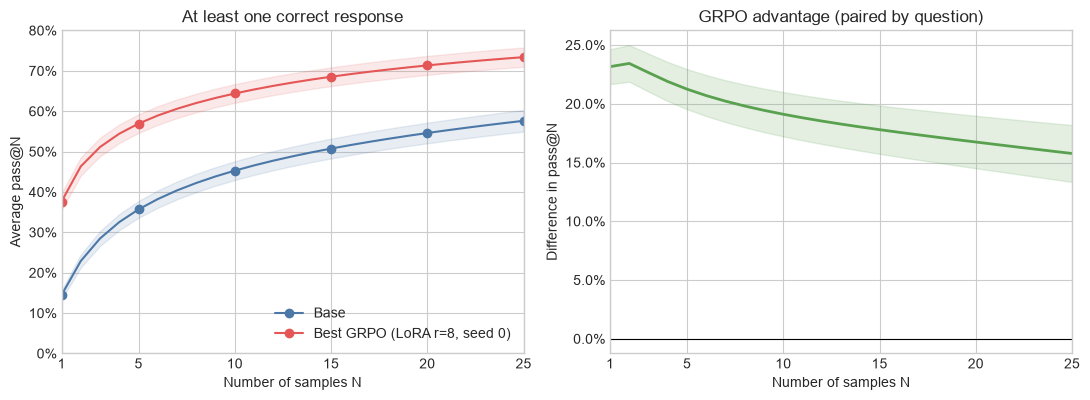

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = {"base": "#4C78A8", "grpo": "#E45756"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

for name, label in (("base", "Base"), ("grpo", "Best GRPO (LoRA r=8, seed 0)")):
    values = per_question[name]
    mean = values.mean(0)
    se = values.std(0, ddof=1) / np.sqrt(len(values))
    axes[0].plot(N, mean, marker="o", markevery=[0, 4, 9, 14, 19, 24], color=colors[name], label=label)
    axes[0].fill_between(N, mean - 1.96 * se, mean + 1.96 * se, color=colors[name], alpha=.13)

axes[0].set(title="At least one correct response", xlabel="Number of samples N", ylabel="Average pass@N", xlim=(1, 25), ylim=(0, .8))
axes[0].legend(loc="lower right")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].plot(N, delta, color="#59A14F", linewidth=2)
axes[1].fill_between(N, delta - 1.96 * delta_se, delta + 1.96 * delta_se, color="#59A14F", alpha=.16)
axes[1].axhline(0, color="black", linewidth=.8)
axes[1].set(title="GRPO advantage (paired by question)", xlabel="Number of samples N", ylabel="Difference in pass@N", xlim=(1, 25))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for axis in axes: axis.set_xticks([1, 5, 10, 15, 20, 25])
fig.tight_layout()
# fig.savefig(FIGURES / "04_pass_at_n.png", dpi=180, bbox_inches="tight")
plt.show()